In [ ]:
from google.colab import files
import zipfile
import io

uploaded = files.upload()

Saving Cherries_Olives2.zip to Cherries_Olives2.zip


In [ ]:
zf = zipfile.ZipFile(io.BytesIO(uploaded['Cherries_Olives2.zip']), "r")
zf.extractall()

In [ ]:
import keras
import os, shutil
# load cat and dog images

# Directories for training, validation, and test sets
train_dir = './training'
valid_dir ='./validation'
test_dir = './testing'

In [ ]:
# Preprocess the images: read the image files;
# decode the jpg to RBG grids of pixels (150x150);
# convert to float point tensors; rescale the pixel values

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be rescaled by 1./255
print('\n')
print('Preprocess the training set')
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
    )

train_generator = train_datagen.flow_from_directory(
        directory = train_dir,      # The target directory
        target_size=(150, 150),     # Being resized to 150x150
        batch_size=5,
        class_mode='binary',        # Binary classification
        seed = 63
        )

# Each batch has 20 samples, and each sample is an 150x150 RGB image
# (shape 150,150,3) and binary labels.
print('\n')
print('In the first batch')
(data_batch, labels_batch) = train_generator[0]
print('Data batch shape:', data_batch.shape)
print('Labels batch shape:', labels_batch.shape)




Preprocess the training set
Found 49 images belonging to 2 classes.


In the first batch
Data batch shape: (5, 150, 150, 3)
Labels batch shape: (5,)


In [ ]:
# preprocess the validation set
print('\n')
print('Preprocess the validation set')
valid_datagen = ImageDataGenerator(rescale=1./255)
valid_generator = valid_datagen.flow_from_directory(
        directory = valid_dir,
        target_size=(150, 150),
        batch_size=5,
        class_mode='binary',
        seed = 63
        )

# preprocess the test set
print('\n')
print('Preprocess the test set')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        directory = test_dir,
        target_size=(150, 150),
        batch_size=1,
        class_mode='binary',
        shuffle = False,
        seed = 63
        )




Preprocess the validation set
Found 6 images belonging to 2 classes.


Preprocess the test set
Found 6 images belonging to 2 classes.


In [ ]:
# build a CNN
from keras import layers
from keras import models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2))) # stride 2 (downsampled by a factor of 2)
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten()) # Flatten the 3D outputs to 1D before adding a few Dense layers
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid')) # binary classificaiton
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# configure the model
from keras import optimizers
model.compile(loss='binary_crossentropy',
#              optimizer=optimizers.RMSprop(learning_rate=1e-4),
                optimizer = 'rmsprop',
              metrics=['acc'])

# train the model
history = model.fit(
      train_generator,
      steps_per_epoch=100,      # 2000/20
      epochs=50,
      validation_data=valid_generator,
      validation_steps=50, # 1000/20
      )


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.4184 - loss: 1.4065 - val_acc: 0.5000 - val_loss: 0.6530
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - acc: 0.6062 - loss: 0.8145 - val_acc: 0.8333 - val_loss: 0.4548
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.6490 - loss: 0.6662 - val_acc: 0.8333 - val_loss: 0.3988
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - acc: 0.8965 - loss: 0.2396 - val_acc: 0.5000 - val_loss: 2.4086
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.8085 - loss: 0.9600 - val_acc: 1.0000 - val_loss: 0.1615
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.8034 - loss: 0.3839 - val_acc: 0.8333 - val_loss: 0.1768
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - acc: 0.9181 - loss: 0.2574 - val_acc: 1.0000 - val_loss: 0.0159
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8753 - loss: 0.3338 - val_acc: 0.8333 - val_loss: 0.3050
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/

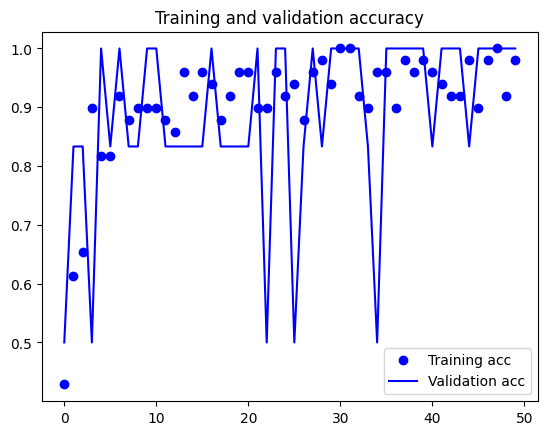

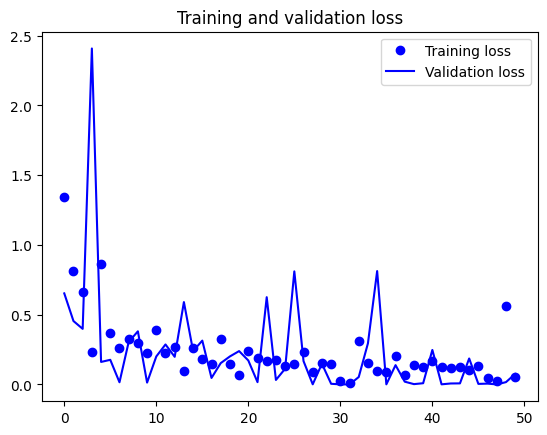

In [ ]:
# plot the training and validation scores
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()


In [ ]:
# evaludate the model
# Evaluation

eval_test = model.evaluate(test_generator, steps=1000)
print("The test score (accuracy) is {}%".format(eval_test[1]*100))


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 82us/step - acc: 0.8340 - loss: 0.9868     
The test score (accuracy) is 83.33333134651184%


In [ ]:
import numpy as np
import pandas as pd
test_generator.reset()
# Replace predict_generator with predict
pred=model.predict(test_generator, steps=1000, verbose=1)
predicted_class_indices= np.where(pred > 0.5, 1, 0)
predicted_class_indices=predicted_class_indices.reshape(-1)
labels = (train_generator.class_indices)
labels = dict((v,k) for k,v in labels.items())
predictions = [labels[k] for k in predicted_class_indices]
filenames=test_generator.filenames
results=pd.DataFrame({"Filename":filenames,
                      "Predictions":predictions})
results.to_csv("results_DA.csv",index=False)

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 76us/step 


In [ ]:
# initiate a pre-trained convolutional base VGG16
from keras.applications import VGG16

conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))
conv_base.summary()



Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# build the network
from keras import models
from keras import layers

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

conv_base.trainable = False
model.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,910,017 (72.14 MB)

 Trainable params: 4,195,329 (16.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# configure the model
from keras import optimizers
model.compile(loss='binary_crossentropy',
#              optimizer=optimizers.RMSprop(lr=2e-5),
              optimizer = 'rmsprop',
              metrics=['acc'])

# train the model
history = model.fit(
      train_generator,
      steps_per_epoch=100,
      epochs=50,
      validation_data=valid_generator,
      validation_steps=50       # 1000/20
      )


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - acc: 0.6305 - loss: 2.4349 - val_acc: 0.5000 - val_loss: 1.4592
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - acc: 0.7911 - loss: 0.8317 - val_acc: 1.0000 - val_loss: 0.0932
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - acc: 0.7434 - loss: 0.8182 - val_acc: 1.0000 - val_loss: 0.0829
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - acc: 0.8133 - loss: 0.4729 - val_acc: 1.0000 - val_loss: 0.0715
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - acc: 0.8731 - loss: 0.3608 - val_acc: 1.0000 - val_loss: 0.1112
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - acc: 0.6933 - loss: 1.2911 - val_acc: 1.0000 - val_loss: 0.1094
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - acc: 0.8828 - loss: 0.3674 - val_acc: 0.8333 - val_loss: 0.6134
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - acc: 0.8795 - loss: 0.2979 - val_acc: 0.6667 - val_loss: 1.1757
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9

In [ ]:
# evaludate the model
# Evaluation

eval_test = model.evaluate(test_generator, steps=1000)
print("The test score (accuracy) is {}%".format(eval_test[1]*100))

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - acc: 0.8340 - loss: 0.2555  
The test score (accuracy) is 83.33333134651184%


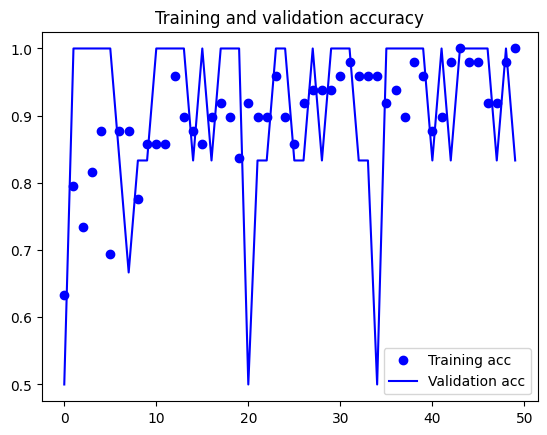

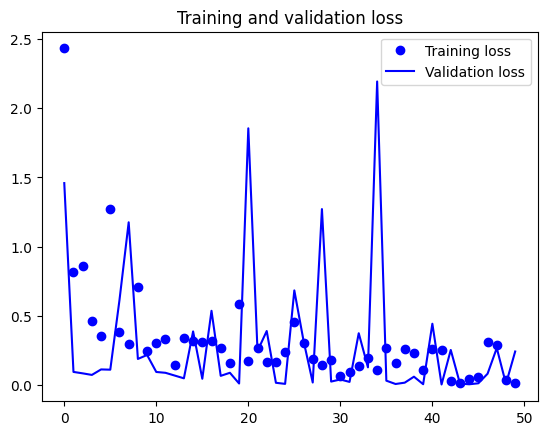

In [ ]:
# plot the training and validation scores
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:
# unfreeze the top block of convolutional base
conv_base.trainable = True

set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

Epoch 1/7
 10/100 ━━━━━━━━━━━━━━━━━━━━ 1:29 1000ms/step - acc: 1.0000 - loss: 1.1372e-04

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - acc: 1.0000 - loss: 3.7568e-04 - val_acc: 1.0000 - val_loss: 7.9651e-05
Epoch 2/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - acc: 1.0000 - loss: 3.6447e-04 - val_acc: 1.0000 - val_loss: 1.4122e-06
Epoch 3/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - acc: 1.0000 - loss: 0.0018 - val_acc: 1.0000 - val_loss: 0.0038
Epoch 4/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - acc: 1.0000 - loss: 2.0817e-04 - val_acc: 1.0000 - val_loss: 5.5221e-04
Epoch 5/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - acc: 1.0000 - loss: 3.9819e-04 - val_acc: 1.0000 - val_loss: 0.0015
Epoch 6/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - acc: 1.0000 - loss: 0.0047 - val_acc: 1.0000 - val_loss: 2.9007e-06
Epoch 7/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - acc: 1.0000 - loss: 4.1440e-04 - val_acc: 1.0000 - val_loss: 1.0026e-04


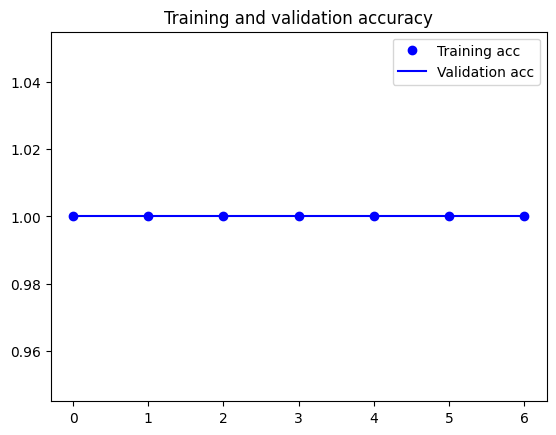

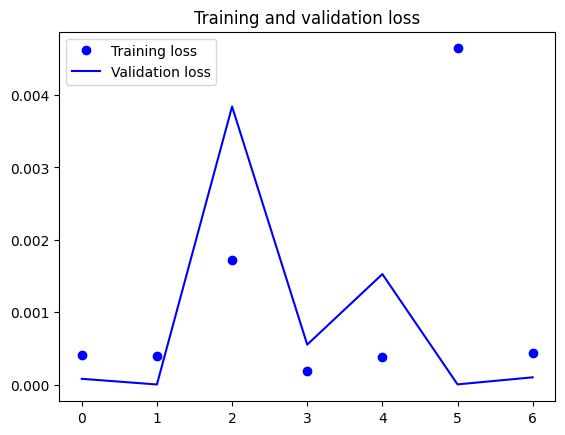

In [ ]:
# fine-tuning
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(1e-5),
              metrics=['acc'])

history = model.fit(
      train_generator,
      steps_per_epoch=100,
      epochs=7,
      validation_data=valid_generator,
      validation_steps=50)

# plot the training and validation scores
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()



In [ ]:
# evaludate the model
eval_test = model.evaluate(test_generator, steps=1000)
print("The test score (accuracy) is {}%".format(eval_test[1]*100))

# output the predictions compared to the targets
import numpy as np
import pandas as pd
test_generator.reset()
pred=model.predict(test_generator, steps=1000, verbose=1)
predicted_class_indices= np.where(pred > 0.5, 1, 0)
predicted_class_indices=predicted_class_indices.reshape(-1)
labels = (train_generator.class_indices)
labels = dict((v,k) for k,v in labels.items())
predictions = [labels[k] for k in predicted_class_indices]
filenames=test_generator.filenames
results=pd.DataFrame({"Filename":filenames,
                      "Predictions":predictions})
results.to_csv("results_FE.csv",index=False)

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - acc: 0.8340 - loss: 0.2263  
The test score (accuracy) is 83.33333134651184%
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step  


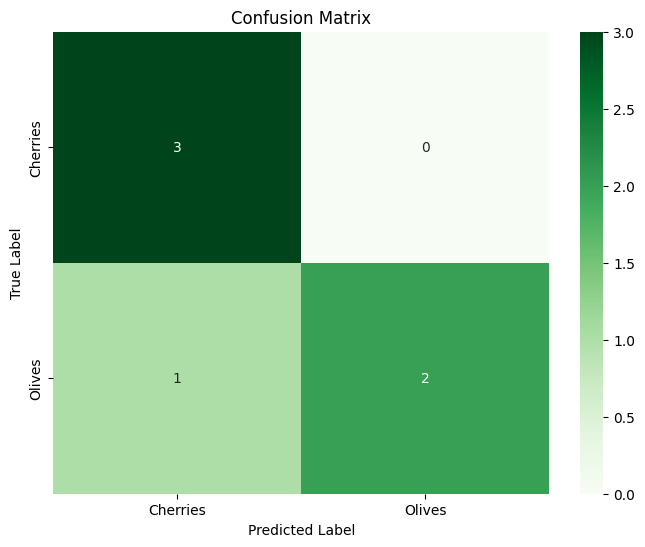

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get the true labels from the test generator
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_class_indices)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


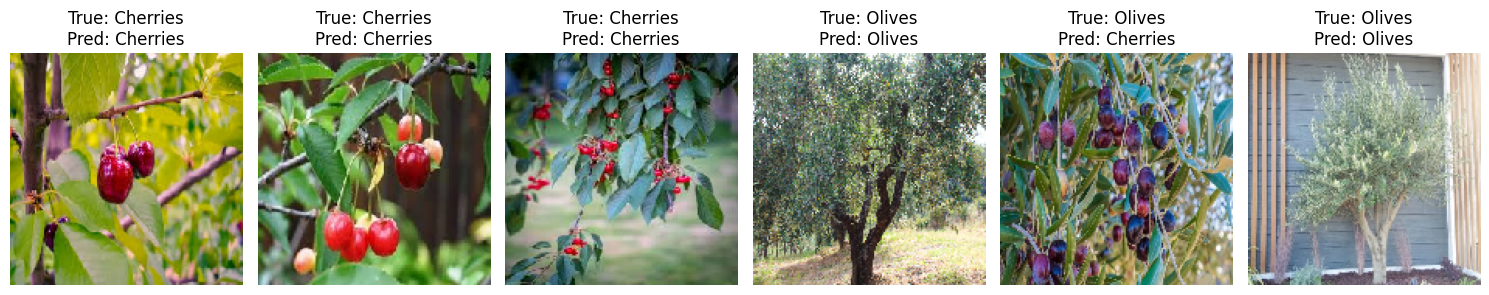

In [ ]:
import matplotlib.pyplot as plt
# Display images with their true and predicted labels
num_images_to_show = 6

plt.figure(figsize=(15, 15))

for i in range(num_images_to_show):
    # Get image and label from the generator
    img, true_label = test_generator[i]
    img = img[0] # Get the single image from the batch
    true_label = int(true_label[0]) # Get the single label

    # Get the predicted label
    predicted_label = predicted_class_indices[i]

    # Map the integer labels back to class names
    true_class_name = class_labels[true_label]
    predicted_class_name = class_labels[predicted_label]

    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(img)
    plt.title(f'True: {true_class_name}\nPred: {predicted_class_name}')
    plt.axis('off')

plt.tight_layout()
plt.show()